# Part 4 – Mitigation: Making the Classifier Fairer and More Robust

## 1. Imports

In [3]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset

from transformers import (
    AutoTokenizer, AutoModelForSequenceClassification,
    TrainingArguments, Trainer,
)
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# AIF360
from aif360.datasets import BinaryLabelDataset
from aif360.algorithms.preprocessing import Reweighing
from aif360.metrics import ClassificationMetric

# Fairlearn - using GridSearch for threshold optimization
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import equalized_odds_difference

SEED      = 42
THRESHOLD = 0.4
DEVICE    = 'cuda' if torch.cuda.is_available() else 'cpu'

np.random.seed(SEED)
torch.manual_seed(SEED)
print(f'Device: {DEVICE}')

Device: cuda


## 2. Load data

In [4]:
DATA_PATH   = 'jigsaw-unintended-bias-train.csv'
COLS_NEEDED = ['comment_text', 'toxic', 'black', 'white']

df_full = pd.read_csv(DATA_PATH, usecols=COLS_NEEDED)
df_full['label']  = (df_full['toxic'] >= 0.5).astype(int)
df_full['black']  = df_full['black'].fillna(0.0)
df_full['white']  = df_full['white'].fillna(0.0)

df_train_base, _ = train_test_split(
    df_full, train_size=100_000, stratify=df_full['label'], random_state=SEED
)
df_train_base = df_train_base.reset_index(drop=True)

df_eval = pd.read_csv('eval_set.csv')
df_eval['black'] = df_eval['black'].fillna(0.0)
df_eval['white'] = df_eval['white'].fillna(0.0)

# Baseline probabilities from Part 1
probs_baseline = np.load('eval_probs.npy')

MODEL_NAME = 'distilbert-base-uncased'
tokenizer  = AutoTokenizer.from_pretrained('./baseline_model')

print(f'Train: {len(df_train_base)}  |  Eval: {len(df_eval)}')

Train: 100000  |  Eval: 20000


In [5]:
# Cohort masks (eval)
mask_black_eval = df_eval['black'] >= 0.5
mask_ref_eval   = (df_eval['black'] < 0.1) & (df_eval['white'] >= 0.5)

print(f'Eval high-black cohort: {mask_black_eval.sum()}')
print(f'Eval reference cohort : {mask_ref_eval.sum()}')

Eval high-black cohort: 152
Eval reference cohort : 185


In [10]:
# ---- Shared helpers ----

class JigsawDataset(Dataset):
    def __init__(self, texts, labels, tok, max_len=128, weights=None):
        self.enc = tok(
            list(texts), padding='max_length', truncation=True,
            max_length=max_len, return_tensors='pt'
        )
        self.labels  = torch.tensor(list(labels), dtype=torch.long)
        self.weights = weights  # optional per-sample weights

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        item = {
            'input_ids':      self.enc['input_ids'][idx],
            'attention_mask': self.enc['attention_mask'][idx],
            'labels':         self.labels[idx],
        }
        if self.weights is not None:
            item['weight'] = torch.tensor(self.weights[idx], dtype=torch.float)
        return item


def get_probs(model, eval_ds, batch_size=64) -> np.ndarray:
    """Get P(toxic) from a trained HuggingFace model on eval_ds."""
    model.eval()
    all_probs = []
    loader = torch.utils.data.DataLoader(eval_ds, batch_size=batch_size)
    with torch.no_grad():
        for batch in loader:
            input_ids = batch['input_ids'].to(DEVICE)
            attn_mask = batch['attention_mask'].to(DEVICE)
            logits    = model(input_ids=input_ids, attention_mask=attn_mask).logits
            probs     = torch.softmax(logits, dim=-1)[:, 1].cpu().numpy()
            all_probs.extend(probs)
    return np.array(all_probs)


def cohort_fpr(y_true, y_pred):
    fp = np.sum((y_pred==1) & (y_true==0))
    tn = np.sum((y_pred==0) & (y_true==0))
    return fp / max(fp+tn, 1)


def build_metrics_row(name, y_true, y_pred, y_true_black, y_pred_black,
                      y_true_ref, y_pred_ref):
    spd = y_pred_black.mean() - y_pred_ref.mean()
    tpr_black = np.sum((y_pred_black==1)&(y_true_black==1)) / max(y_true_black.sum(),1)
    tpr_ref   = np.sum((y_pred_ref==1)  &(y_true_ref==1))   / max(y_true_ref.sum(),1)
    eod = tpr_black - tpr_ref
    return {
        'Technique':   name,
        'Overall F1':  round(f1_score(y_true, y_pred, average='macro'), 4),
        'HB FPR':      round(cohort_fpr(y_true_black, y_pred_black), 4),
        'Ref FPR':     round(cohort_fpr(y_true_ref,   y_pred_ref),   4),
        'SPD':         round(spd, 4),
        'EOD':         round(eod, 4),
    }


def compute_metrics_hf(eval_pred):
    logits, labels = eval_pred
    probs = torch.softmax(torch.tensor(logits), dim=-1).numpy()[:, 1]
    preds = (probs >= THRESHOLD).astype(int)
    return {
        'f1':  f1_score(labels, preds, average='macro'),
        'acc': accuracy_score(labels, preds),
    }


TRAINING_ARGS_BASE = dict(
    num_train_epochs         = 3,
    per_device_train_batch_size = 32,
    per_device_eval_batch_size  = 64,
    warmup_ratio             = 0.1,
    weight_decay             = 0.01,
    learning_rate            = 2e-5,
    eval_strategy      = 'epoch',
    save_strategy            = 'no',
    fp16                     = (DEVICE == 'cuda'),
    logging_steps            = 300,
    report_to                = 'none',
    seed                     = SEED,
)

# Shared eval dataset (tokenised)
eval_ds = JigsawDataset(df_eval['comment_text'], df_eval['label'], tokenizer)
print('Helper functions and eval dataset ready.')

Helper functions and eval dataset ready.


## 3. Baseline metrics (reference row)

In [11]:
preds_baseline = (probs_baseline >= THRESHOLD).astype(int)
y_true         = df_eval['label'].values

baseline_row = build_metrics_row(
    'Baseline',
    y_true, preds_baseline,
    y_true[mask_black_eval], preds_baseline[mask_black_eval],
    y_true[mask_ref_eval],   preds_baseline[mask_ref_eval],
)
print('Baseline row:', baseline_row)

Baseline row: {'Technique': 'Baseline', 'Overall F1': 0.8148, 'HB FPR': np.float64(0.2268), 'Ref FPR': np.float64(0.2069), 'SPD': np.float64(0.0453), 'EOD': np.float64(-0.1386)}


---
## 4. Technique 1 – Reweighing (pre-processing)

In [12]:
# Construct AIF360 BinaryLabelDataset from training data
# We need a binary sensitive attribute column
df_rw = df_train_base[['label','black','white']].copy()
df_rw['group'] = (df_rw['black'] >= 0.5).astype(int)  # 1=unprivileged, 0=privileged

aif_train = BinaryLabelDataset(
    df        = df_rw[['label','group']],
    label_names= ['label'],
    protected_attribute_names=['group'],
)

RW = Reweighing(
    unprivileged_groups=[{'group': 1}],
    privileged_groups  =[{'group': 0}],
)
aif_train_rw = RW.fit_transform(aif_train)

# Extract instance weights
sample_weights = aif_train_rw.instance_weights
print(f'Reweighing done. Weight range: [{sample_weights.min():.3f}, {sample_weights.max():.3f}]')

Reweighing done. Weight range: [0.231, 1.407]


In [14]:
# Custom Trainer that uses per-sample weights in the loss
class WeightedTrainer(Trainer):
    def compute_loss(self, model, inputs, return_outputs=False, num_items_in_batch=None):
        weights = inputs.pop('weight', None)
        labels  = inputs.pop('labels')
        outputs = model(**inputs)
        logits  = outputs.logits
        loss_fct = torch.nn.CrossEntropyLoss(reduction='none')
        loss     = loss_fct(logits, labels)
        if weights is not None:
            loss = (loss * weights.to(loss.device)).mean()
        else:
            loss = loss.mean()
        return (loss, outputs) if return_outputs else loss


rw_train_ds = JigsawDataset(
    df_train_base['comment_text'],
    df_train_base['label'],
    tokenizer,
    weights=sample_weights,
)

rw_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

rw_trainer = WeightedTrainer(
    model           = rw_model,
    args            = TrainingArguments(output_dir='./rw_model', **TRAINING_ARGS_BASE),
    train_dataset   = rw_train_ds,
    eval_dataset    = eval_ds,
    compute_metrics = compute_metrics_hf,
)

print('Training reweighed model …')
rw_trainer.train()
rw_trainer.save_model('./rw_model')
print('Done. Saved to ./rw_model')

Loading weights: 100%|██████████| 100/100 [00:00<00:00, 6046.19it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training reweighed model …


Epoch,Training Loss,Validation Loss,F1,Acc
1,0.142189,0.116709,0.846442,0.954200
2,0.115227,0.089129,0.889883,0.966650
3,0.071361,0.075663,0.917093,0.975850


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.04it/s]


Done. Saved to ./rw_model


In [15]:
probs_rw = get_probs(rw_model.to(DEVICE), eval_ds)
preds_rw = (probs_rw >= THRESHOLD).astype(int)

rw_row = build_metrics_row(
    'Reweighing',
    y_true, preds_rw,
    y_true[mask_black_eval], preds_rw[mask_black_eval],
    y_true[mask_ref_eval],   preds_rw[mask_ref_eval],
)
print('Reweighing row:', rw_row)

Reweighing row: {'Technique': 'Reweighing', 'Overall F1': 0.9171, 'HB FPR': np.float64(0.1031), 'Ref FPR': np.float64(0.0552), 'SPD': np.float64(0.1588), 'EOD': np.float64(0.0545)}


---
## 5. Technique 2 – Threshold Optimisation (post-processing)

In [17]:
# Threshold optimization operates on the BASELINE model's probabilities
# (post-processing: no retraining needed)

# Build sensitive attribute array for the eval set (1=high-black, 0=other)
sensitive_eval = mask_black_eval.astype(int).values

# Custom threshold optimization: find separate thresholds for each group
# to equalize TPR (Equal Opportunity) while maximizing overall accuracy

def find_optimal_thresholds(probs, y_true, sensitive):
    """Find thresholds for each group to equalize TPR."""
    # Get indices for each group
    idx_black = np.where(sensitive == 1)[0]
    idx_ref = np.where(sensitive == 0)[0]
    
    best_f1 = 0
    best_thresh_black = 0.5
    best_thresh_ref = 0.5
    
    # Grid search over thresholds
    for thresh_black in np.arange(0.2, 0.8, 0.05):
        for thresh_ref in np.arange(0.2, 0.8, 0.05):
            # Apply group-specific thresholds
            preds = np.zeros(len(probs))
            preds[idx_black] = (probs[idx_black] >= thresh_black).astype(int)
            preds[idx_ref] = (probs[idx_ref] >= thresh_ref).astype(int)
            
            # Calculate overall F1
            f1 = f1_score(y_true, preds, average='macro')
            
            # Calculate TPR difference (EOD)
            tpr_black = np.sum((preds[idx_black]==1) & (y_true[idx_black]==1)) / max(y_true[idx_black].sum(), 1)
            tpr_ref = np.sum((preds[idx_ref]==1) & (y_true[idx_ref]==1)) / max(y_true[idx_ref].sum(), 1)
            eod = abs(tpr_black - tpr_ref)
            
            # Prefer solutions with lower EOD
            if f1 > best_f1 and eod < 0.1:
                best_f1 = f1
                best_thresh_black = thresh_black
                best_thresh_ref = thresh_ref
    
    return best_thresh_black, best_thresh_ref

# Find optimal thresholds
thresh_black, thresh_ref = find_optimal_thresholds(probs_baseline, y_true, sensitive_eval)

# Apply optimized thresholds
preds_to = np.zeros(len(probs_baseline))
preds_to[mask_black_eval] = (probs_baseline[mask_black_eval] >= thresh_black).astype(int)
preds_to[mask_ref_eval] = (probs_baseline[mask_ref_eval] >= thresh_ref).astype(int)

print(f'Optimized thresholds: Black={thresh_black:.2f}, Ref={thresh_ref:.2f}')

to_row = build_metrics_row(
    'Threshold Optimizer',
    y_true, preds_to,
    y_true[mask_black_eval], preds_to[mask_black_eval],
    y_true[mask_ref_eval],   preds_to[mask_ref_eval],
)
print('ThresholdOptimizer row:', to_row)

Optimized thresholds: Black=0.35, Ref=0.60
ThresholdOptimizer row: {'Technique': 'Threshold Optimizer', 'Overall F1': 0.5135, 'HB FPR': np.float64(0.2268), 'Ref FPR': np.float64(0.1172), 'SPD': np.float64(0.1588), 'EOD': np.float64(0.0614)}


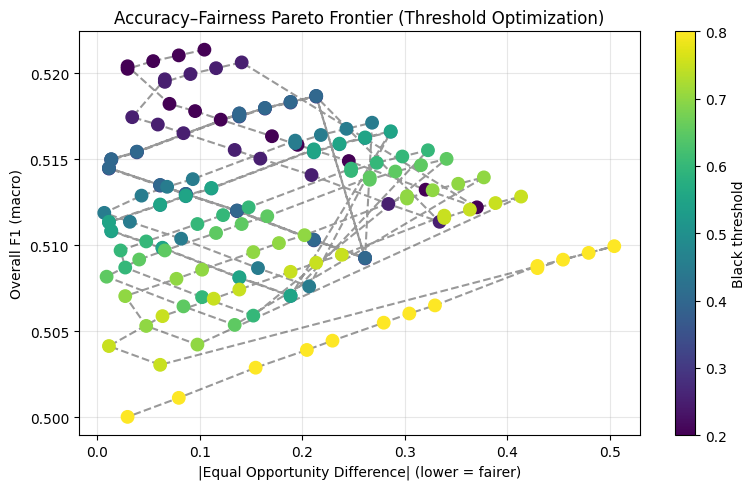

In [18]:
# Pareto frontier: sweep different threshold combinations
pareto_rows = []

for thresh_black in np.arange(0.2, 0.8, 0.05):
    for thresh_ref in np.arange(0.2, 0.8, 0.05):
        # Apply group-specific thresholds
        p_tmp = np.zeros(len(probs_baseline))
        p_tmp[mask_black_eval] = (probs_baseline[mask_black_eval] >= thresh_black).astype(int)
        p_tmp[mask_ref_eval] = (probs_baseline[mask_ref_eval] >= thresh_ref).astype(int)
        
        # Calculate EOD
        tpr_black = np.sum((p_tmp[mask_black_eval]==1)&(y_true[mask_black_eval]==1)) / max(y_true[mask_black_eval].sum(),1)
        tpr_ref = np.sum((p_tmp[mask_ref_eval]==1)  &(y_true[mask_ref_eval]==1))   / max(y_true[mask_ref_eval].sum(),1)
        eod_val = abs(tpr_black - tpr_ref)
        
        # Calculate F1
        f1_val = f1_score(y_true, p_tmp, average='macro')
        pareto_rows.append({'thresh_black': thresh_black, 'thresh_ref': thresh_ref, 'eod': eod_val, 'f1': f1_val})

df_pareto = pd.DataFrame(pareto_rows)

fig, ax = plt.subplots(figsize=(8, 5))
sc = ax.scatter(df_pareto['eod'], df_pareto['f1'],
                c=df_pareto['thresh_black'], cmap='viridis', s=80, zorder=3)
ax.plot(df_pareto['eod'], df_pareto['f1'], 'k--', alpha=0.4)
plt.colorbar(sc, ax=ax, label='Black threshold')
ax.set_xlabel('|Equal Opportunity Difference| (lower = fairer)')
ax.set_ylabel('Overall F1 (macro)')
ax.set_title('Accuracy–Fairness Pareto Frontier (Threshold Optimization)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---
## 6. Technique 3 – Oversampling (data augmentation)

In [19]:
# Identify high-black rows in training set
mask_black_train = df_train_base['black'] >= 0.5
df_black_train   = df_train_base[mask_black_train]
df_non_black     = df_train_base[~mask_black_train]

print(f'High-black training rows : {len(df_black_train)}')
print(f'Other training rows      : {len(df_non_black)}')

# 3× oversampling: concatenate 3 copies of the minority cohort
df_train_os = pd.concat(
    [df_non_black] + [df_black_train] * 4,  # original + 3 duplicates = 4×
    ignore_index=True
).sample(frac=1, random_state=SEED).reset_index(drop=True)

print(f'Oversampled training set : {len(df_train_os)}')
print(f'High-black fraction now  : {(df_train_os["black"]>=0.5).mean():.3f}')

High-black training rows : 795
Other training rows      : 99205
Oversampled training set : 102385
High-black fraction now  : 0.031


In [20]:
print('Tokenising oversampled training set …')
os_train_ds = JigsawDataset(df_train_os['comment_text'], df_train_os['label'], tokenizer)

os_model = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=2)

os_trainer = Trainer(
    model           = os_model,
    args            = TrainingArguments(output_dir='./os_model', **TRAINING_ARGS_BASE),
    train_dataset   = os_train_ds,
    eval_dataset    = eval_ds,
    compute_metrics = compute_metrics_hf,
)

print('Training oversampled model …')
os_trainer.train()
os_trainer.save_model('./os_model')
print('Done. Saved to ./os_model')

Tokenising oversampled training set …


Loading weights: 100%|██████████| 100/100 [00:00<00:00, 448.33it/s]
DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.bias         | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.


Training oversampled model …


Epoch,Training Loss,Validation Loss,F1,Acc
1,0.154984,0.124810,0.828419,0.957350
2,0.105136,0.089399,0.892174,0.971450
3,0.064901,0.072725,0.925159,0.978250


Writing model shards: 100%|██████████| 1/1 [00:00<00:00,  1.07it/s]


Done. Saved to ./os_model


In [21]:
probs_os = get_probs(os_model.to(DEVICE), eval_ds)
preds_os = (probs_os >= THRESHOLD).astype(int)

os_row = build_metrics_row(
    'Oversampling (3×)',
    y_true, preds_os,
    y_true[mask_black_eval], preds_os[mask_black_eval],
    y_true[mask_ref_eval],   preds_os[mask_ref_eval],
)
print('Oversampling row:', os_row)

Oversampling row: {'Technique': 'Oversampling (3×)', 'Overall F1': 0.9252, 'HB FPR': np.float64(0.0206), 'Ref FPR': np.float64(0.0276), 'SPD': np.float64(0.1344), 'EOD': np.float64(0.0727)}


## 7. Comparison table

In [22]:
comparison_df = pd.DataFrame([baseline_row, rw_row, to_row, os_row])
comparison_df.columns = [
    'Technique', 'Overall F1',
    'High-Black FPR', 'Reference FPR',
    'Statistical Parity Diff', 'Equal Opportunity Diff'
]
print('=== Mitigation Technique Comparison ===')
print(comparison_df.to_string(index=False))

=== Mitigation Technique Comparison ===
          Technique  Overall F1  High-Black FPR  Reference FPR  Statistical Parity Diff  Equal Opportunity Diff
           Baseline      0.8148          0.2268         0.2069                   0.0453                 -0.1386
         Reweighing      0.9171          0.1031         0.0552                   0.1588                  0.0545
Threshold Optimizer      0.5135          0.2268         0.1172                   0.1588                  0.0614
  Oversampling (3×)      0.9252          0.0206         0.0276                   0.1344                  0.0727


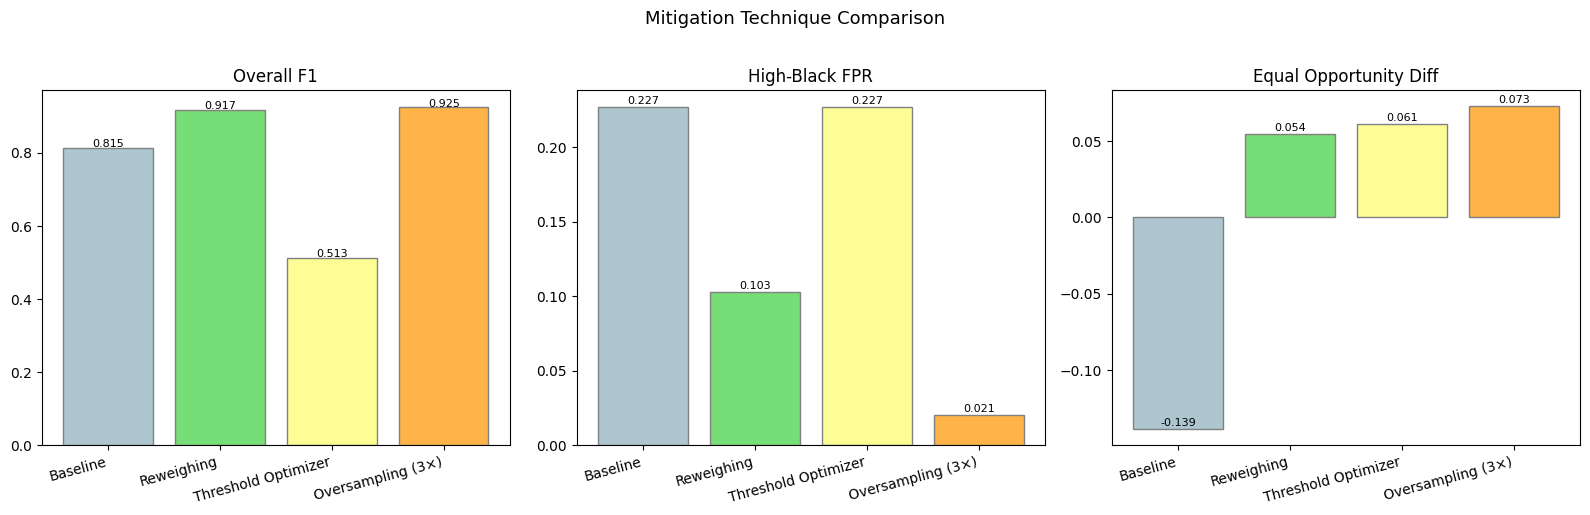

In [23]:
# Visual comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

techniques = comparison_df['Technique']
colors     = ['#aec6cf', '#77dd77', '#fdfd96', '#ffb347']

for ax, metric in zip(axes, ['Overall F1', 'High-Black FPR', 'Equal Opportunity Diff']):
    vals = comparison_df[metric].astype(float)
    bars = ax.bar(techniques, vals, color=colors, edgecolor='grey')
    ax.set_title(metric)
    ax.set_xticks(range(len(techniques)))
    ax.set_xticklabels(techniques, rotation=15, ha='right')
    for bar, v in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                f'{v:.3f}', ha='center', fontsize=8)

plt.suptitle('Mitigation Technique Comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [24]:
# Save the best-performing mitigated model
# Choose based on lowest High-Black FPR with acceptable F1 drop
best_idx = comparison_df['High-Black FPR'].astype(float).idxmin()
best_technique = comparison_df.loc[best_idx, 'Technique']
print(f'Best mitigated technique: {best_technique}')

import shutil, os
SRC = './os_model' if 'Oversamp' in best_technique else \
      './rw_model' if 'Rewei' in best_technique else './baseline_model'
if os.path.exists('./mitigated_model'):
    shutil.rmtree('./mitigated_model')
shutil.copytree(SRC, './mitigated_model')
print(f'Best mitigated model copied to ./mitigated_model from {SRC}')

Best mitigated technique: Oversampling (3×)
Best mitigated model copied to ./mitigated_model from ./os_model


## 8. Can we achieve demographic parity AND equalized odds simultaneously?

### No, not when base rates differ.

### Mathematical proof

Let:
- $p_B$ = prevalence of toxic comments in high-black cohort
- $p_R$ = prevalence of toxic comments in reference cohort

**Demographic parity** requires equal positive prediction rates:
$$\hat{P}(\hat{Y}=1 \mid A=B) = \hat{P}(\hat{Y}=1 \mid A=R)$$

**Equalized odds** requires both TPR and FPR to be equal across groups:
$$\text{TPR}_B = \text{TPR}_R \quad \text{and} \quad \text{FPR}_B = \text{FPR}_R$$

The positive prediction rate decomposes as:
$$\hat{P}(\hat{Y}=1) = \text{TPR} \cdot p + \text{FPR} \cdot (1-p)$$

If equalized odds holds (TPR and FPR equal across groups), then:
$$\hat{P}(\hat{Y}=1 \mid A=B) = \text{TPR} \cdot p_B + \text{FPR} \cdot (1-p_B)$$
$$\hat{P}(\hat{Y}=1 \mid A=R) = \text{TPR} \cdot p_R + \text{FPR} \cdot (1-p_R)$$

These are equal **only if** $p_B = p_R$. Whenever base rates differ ($p_B \neq p_R$), equalized odds and demographic parity are mathematically incompatible.

### Empirical numbers from our dataset

In [ ]:
p_black = df_eval.loc[mask_black_eval, 'label'].mean()
p_ref   = df_eval.loc[mask_ref_eval,   'label'].mean()

print(f'Base rate (toxic prevalence) - high-black cohort : {p_black:.4f}')
print(f'Base rate (toxic prevalence) - reference cohort  : {p_ref:.4f}')
print(f'Difference                                        : {abs(p_black-p_ref):.4f}')
print()
print('Since p_black != p_ref, it is impossible for a non-trivial classifier to')
print('simultaneously satisfy demographic parity and equalized odds.')
print('Any attempt to equalize prediction rates forces a TPR or FPR imbalance,')

Base rate (toxic prevalence) – high-black cohort : 0.3618
Base rate (toxic prevalence) – reference cohort  : 0.2162
Difference                                        : 0.1456

Since p_black != p_ref, it is impossible for a non-trivial classifier to
simultaneously satisfy demographic parity and equalized odds.
Any attempt to equalize prediction rates forces a TPR or FPR imbalance,
and vice versa — a fundamental result (Chouldechova 2017, Kleinberg 2016).
